
Running inference on device: cuda
Loading model from: ../networks/final_model.pt
[INFO] Dataset loaded with 50000 signals (normalize=False)
[INFO] Train set: 37500 | Val set: 7500 | Test set: 5000
Loaded batch: 32 signals
Predictions - pos: (32, 1024), heights: (32, 3), widths: (32, 3)


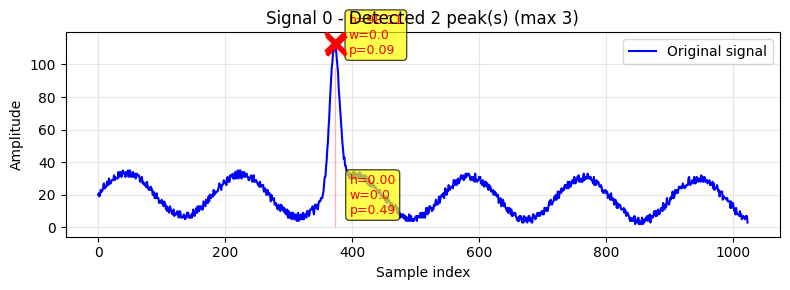

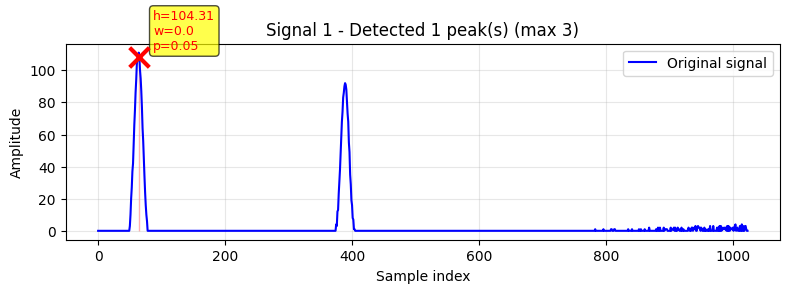

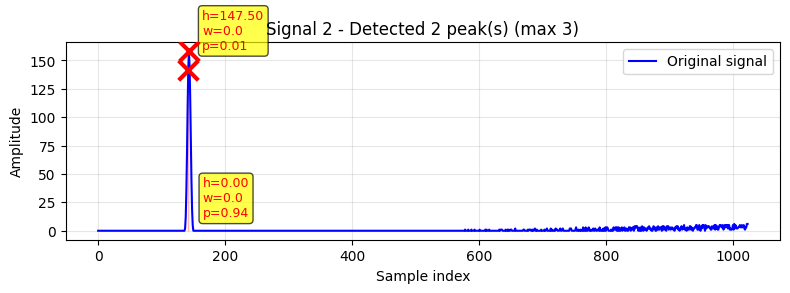

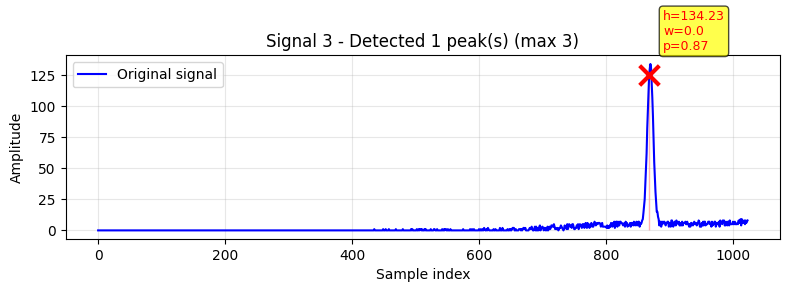

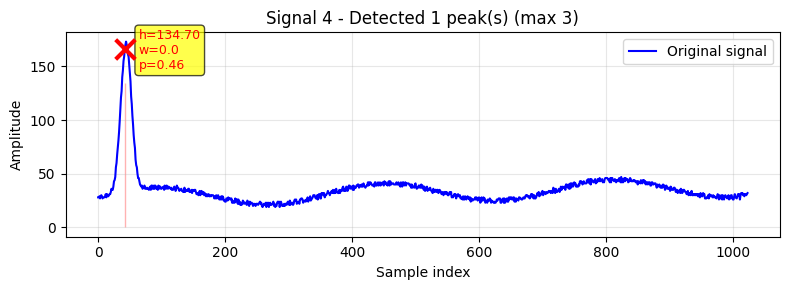

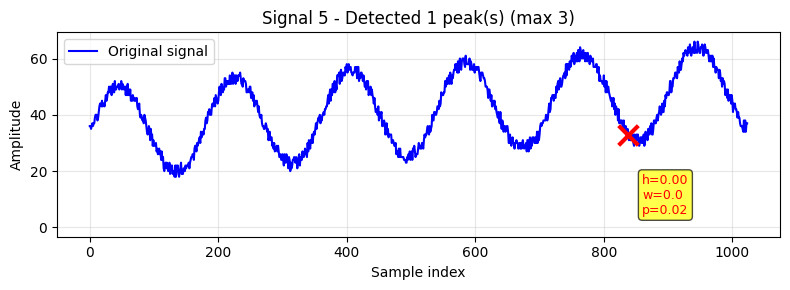

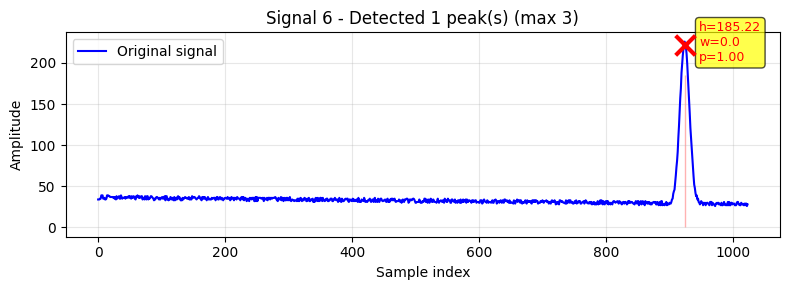

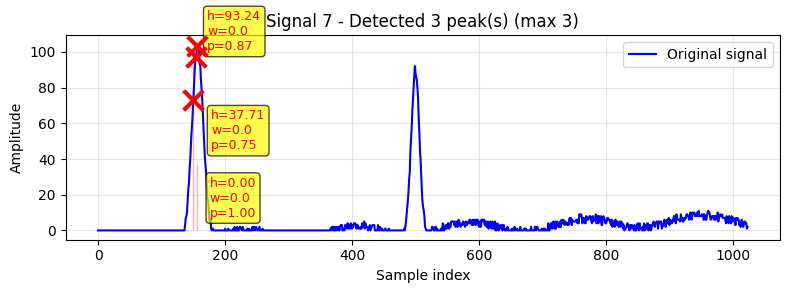

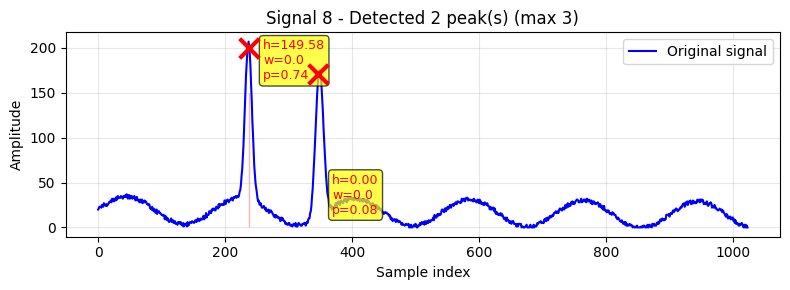

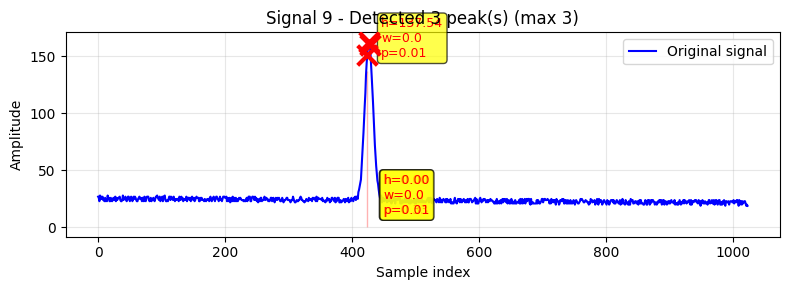

In [13]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
project_root = os.path.abspath('..') 
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from networks.PeakDetectionModel import PeakDetectionModel
from run import prepare_dataset

# -------------------- HARD-CODED PARAMETERS --------------------
signal_path = "../data/signal.raw"
info_path = "../data/info.raw"
chunks = 1024
max_peaks = 3
batch_size = 32
shuffle = True
train_split = 0.75
val_split = 0.15
normalize = False 
seed = 42  

# -------------------- CONFIGURATION --------------------
model_path = "../networks/final_model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    normalize = normalize 
    seed = seed 
    device = device

args = Config()
print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")

# -------------------- DATASET --------------------
_, _, test_loader = prepare_dataset(args)

# -------------------- MODEL --------------------
model = PeakDetectionModel(signal_length=chunks, max_peaks=max_peaks)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# -------------------- INFERENCE ON FIRST BATCH --------------------
with torch.no_grad():
    for signals, true_pos, true_height, true_width in test_loader:
        signals = signals.to(device)
        pred_pos, pred_heights, pred_widths = model(signals.unsqueeze(1))
        
        pred_pos = pred_pos.detach().cpu().numpy()
        pred_heights = pred_heights.detach().cpu().numpy()
        pred_widths = pred_widths.detach().cpu().numpy()
        break 

print(f"Loaded batch: {signals.shape[0]} signals")
print(f"Predictions - pos: {pred_pos.shape}, heights: {pred_heights.shape}, widths: {pred_widths.shape}")

# -------------------- VISUALIZATION: TOP 3 PEAKS --------------------
for i in range(min(10, signals.shape[0])):  # Ridotto a 10 per non sovraccaricare
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]
    widths_pred = pred_widths[i]
    
    plt.figure(figsize=(8, 3))
    plt.plot(signal_example, label="Original signal", linewidth=1.5, color='blue')
    
    threshold = 0.01
    peak_indices = np.where(positions_pred > threshold)[0]
    peak_probs = positions_pred[peak_indices]
    
    # Keep only top-3 peaks with highest probability
    if len(peak_indices) > 3:
        top_3_idx = np.argsort(peak_probs)[-3:]
        peak_indices = peak_indices[top_3_idx]
        peak_probs = peak_probs[top_3_idx]
    
    # Ordina per posizione
    sort_idx = np.argsort(peak_indices)
    peak_indices = peak_indices[sort_idx]
    peak_probs = peak_probs[sort_idx]
    
    num_peaks = len(peak_indices)
    
    if num_peaks > 0:
        # Disegna rettangoli colorati per altezza e larghezza
        for idx in range(num_peaks):
            pos = peak_indices[idx]
            height = heights_pred[idx]
            width = widths_pred[idx]
            
            start = pos - width / 2
            stop = pos + width / 2
            
            # Rettangolo colorato
            plt.fill_between([start, stop], 0, height, 
                           alpha=0.3, color='red')
            
            # Linea orizzontale per l'altezza
            plt.hlines(height, start, stop, colors='red', linewidth=2)
            
            # Marker sulla posizione del picco
            plt.scatter([pos], [signal_example[int(pos)]], 
                       s=200, color='red', marker='x', linewidths=3, zorder=5)
            
            # Annotazione
            plt.annotate(f'h={height:.2f}\nw={width:.1f}\np={peak_probs[idx]:.2f}', 
                        xy=(pos, height),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, color='red',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.title(f"Signal {i} - Detected {num_peaks} peak(s) (max 3)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()